# MDI3003: Advanced Predictive Analytics
## Laboratory Experiment 05: Product and Brand Sentiment Prediction from Tweet Data
**From Classical NLP Baselines to Sequence Models (BiLSTM) and Pretrained Twitter Transformers (BERTweet)**

**Author:** Madhusudhanan G  
**Registration Number:** 23MID0444  
**Faculty:** Dr. Durgesh Kumar  
**School:** School of Computer Science and Engineering (SCOPE), VIT Vellore  
**Academic Term:** Fall Semester 2026-2027  
**Date:** August 25, 2026  

---
### Technical Positioning & Governance Notice
> **Important:** This laboratory treats tweet sentiment analysis as a supervised multiclass text classification task (Negative, Neutral, Positive) targeting explicit service entities (6 major US airlines). Post-label leakage fields (`negativereason`, `airline_sentiment_confidence`) and direct identifiers are strictly excluded from predictors.



In [1]:
!pip -q install vaderSentiment kagglehub

import os, re, json, time, platform, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

SEED = 42
np.random.seed(SEED)
OUT = 'lab05_outputs'
FIG = 'figures'
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)
print('Python:', platform.python_version())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
Python: 3.13.15


In [2]:
dataset_path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("Path to dataset files:", dataset_path)
print("Files:", os.listdir(dataset_path))

TEXT_COL    = 'text'
TARGET_COL  = 'airline_sentiment'
ID_COL      = 'tweet_id'
ENTITY_COL  = 'airline'

csv_file = [f for f in os.listdir(dataset_path) if f.endswith('.csv')][0]
DATA_PATH = os.path.join(dataset_path, csv_file)
print("Using file:", DATA_PATH)

raw = pd.read_csv(DATA_PATH)
required = {TEXT_COL, TARGET_COL}
missing = required - set(raw.columns)
assert not missing, f'Missing required columns: {missing}'

df = raw[[c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL] if c in raw.columns]].copy()
df = df.dropna(subset=[TEXT_COL, TARGET_COL])
df[TEXT_COL] = df[TEXT_COL].astype(str)

print('Shape:', df.shape)
print(df[TARGET_COL].value_counts(dropna=False))

100%|██████████| 2.55M/2.55M [00:00<00:00, 57.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4
Files: ['database.sqlite', 'Tweets.csv']
Using file: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4/Tweets.csv
Shape: (14640, 4)
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [3]:
# Required dataset card (manual section 8.1) — fill/verify before submission
dataset_card = {
    'name': 'Twitter US Airline Sentiment',
    'source': 'https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment',
    'access_date': str(pd.Timestamp.today().date()),
    'license': 'CC BY-NC-SA 4.0',
    'rows': len(df),
    'label_distribution': df[TARGET_COL].value_counts().to_dict(),
    'collection_period': 'February 2015',
    'fields_excluded': ['tweet_id (identifier)', 'negativereason (post-label leakage)',
                         'name/username (identifier)', 'tweet_coord/tweet_location (privacy)',
                         'airline_sentiment_confidence (target leakage)']
}
with open(os.path.join(OUT, 'dataset_card.json'), 'w') as f:
    json.dump(dataset_card, f, indent=2)
dataset_card

{'name': 'Twitter US Airline Sentiment',
 'source': 'https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment',
 'access_date': '2026-08-24',
 'license': 'CC BY-NC-SA 4.0',
 'rows': 14640,
 'label_distribution': {'negative': 9178, 'neutral': 3099, 'positive': 2363},
 'collection_period': 'February 2015',
 'fields_excluded': ['tweet_id (identifier)',
  'negativereason (post-label leakage)',
  'name/username (identifier)',
  'tweet_coord/tweet_location (privacy)',
  'airline_sentiment_confidence (target leakage)']}

Audit: Nulls, Duplicates, Leakage Fields

In [4]:
print('Nulls:\n', df.isna().sum())
print('\nDuplicate tweet IDs:', df[ID_COL].duplicated().sum() if ID_COL in df else 'N/A')
print('Duplicate text:', df[TEXT_COL].duplicated().sum())

leakage_fields = ['airline_sentiment_confidence', 'negativereason', 'negativereason_confidence',
                   'name', 'tweet_coord', 'tweet_location', 'user_timezone']
present_leaks = [c for c in leakage_fields if c in raw.columns]
print('Leakage columns found in raw (excluded from df):', present_leaks)

Nulls:
 tweet_id             0
text                 0
airline_sentiment    0
airline              0
dtype: int64

Duplicate tweet IDs: 155
Duplicate text: 213
Leakage columns found in raw (excluded from df): ['airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'name', 'tweet_coord', 'tweet_location', 'user_timezone']


Minimal Tweet Normalization

In [5]:
def normalize_tweet(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' <URL> ', text)
    text = re.sub(r'@\w+', ' <USER> ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df[TEXT_COL].map(normalize_tweet)
df['tweet_length'] = df['clean_text'].str.split().map(len)
print('Duplicate cleaned text:', df['clean_text'].duplicated().sum())

Duplicate cleaned text: 336


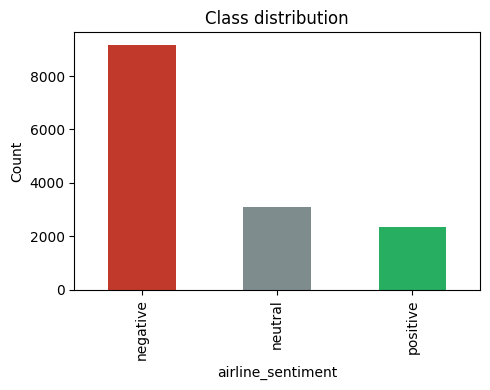

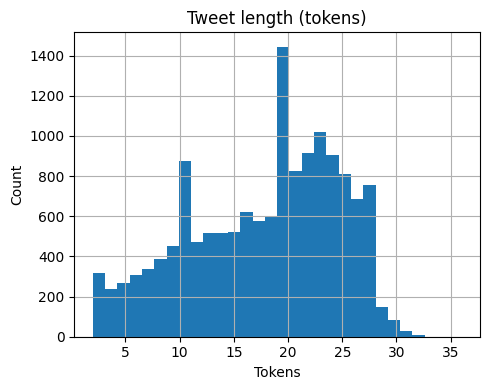

In [6]:
plt.figure(figsize=(5,4))
df[TARGET_COL].value_counts().plot(kind='bar', color=['#c0392b','#7f8c8d','#27ae60'])
plt.title('Class distribution'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig(f'{FIG}/class_distribution.png'); plt.show()

plt.figure(figsize=(5,4))
df['tweet_length'].hist(bins=30)
plt.title('Tweet length (tokens)'); plt.xlabel('Tokens'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig(f'{FIG}/tweet_length.png'); plt.show()

In [7]:
from collections import Counter
def top_terms(texts, n=15):
    c = Counter()
    for t in texts:
        c.update(t.lower().split())
    return c.most_common(n)

for label in df[TARGET_COL].unique():
    print(label, '->', top_terms(df.loc[df[TARGET_COL]==label, 'clean_text'], 10))

neutral -> [('<user>', 3616), ('to', 1657), ('i', 1168), ('the', 970), ('a', 783), ('you', 653), ('on', 645), ('for', 610), ('my', 532), ('<url>', 526)]
positive -> [('<user>', 2690), ('the', 970), ('to', 934), ('for', 667), ('i', 606), ('you', 600), ('a', 519), ('thank', 452), ('and', 444), ('thanks', 397)]
negative -> [('<user>', 10199), ('to', 5999), ('the', 4095), ('i', 3577), ('a', 3159), ('and', 2799), ('for', 2687), ('on', 2667), ('my', 2396), ('flight', 2393)]


In [8]:
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df[TARGET_COL]
)
train_df.to_csv(os.path.join(OUT, 'train_manifest.csv'), index=False)
test_df.to_csv(os.path.join(OUT, 'test_manifest.csv'), index=False)

X_train, y_train = train_df['clean_text'], train_df[TARGET_COL]
X_test, y_test   = test_df['clean_text'], test_df[TARGET_COL]
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (11712,) Test: (2928,)


In [9]:
dummy = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2)),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=SEED))
])
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print('Dummy macro F1:', f1_score(y_test, dummy_pred, average='macro'))
print('Dummy accuracy:', accuracy_score(y_test, dummy_pred))

analyzer = SentimentIntensityAnalyzer()
def vader_label(text):
    c = analyzer.polarity_scores(text)['compound']
    if c >= 0.05: return 'positive'
    if c <= -0.05: return 'negative'
    return 'neutral'

vader_pred = X_test.map(vader_label)
print('VADER macro F1:', f1_score(y_test, vader_pred, average='macro'))
print('VADER accuracy:', accuracy_score(y_test, vader_pred))

baseline_results = pd.DataFrame([
    {'model':'Dummy', 'macro_f1': f1_score(y_test, dummy_pred, average='macro'), 'accuracy': accuracy_score(y_test, dummy_pred)},
    {'model':'VADER', 'macro_f1': f1_score(y_test, vader_pred, average='macro'), 'accuracy': accuracy_score(y_test, vader_pred)},
])
baseline_results

Dummy macro F1: 0.256840926586885
Dummy accuracy: 0.6267076502732241
VADER macro F1: 0.5206462567349533
VADER accuracy: 0.5522540983606558


,model,macro_f1,accuracy
0,Dummy,0.256841,0.626708
1,VADER,0.520646,0.552254


                model  macro_f1_mean  macro_f1_sd  weighted_f1_mean  \
1  LogisticRegression       0.744384     0.008241          0.795471   
2           LinearSVC       0.739502     0.011703          0.796877   
0       MultinomialNB       0.585816     0.015062          0.690117   

   accuracy_mean  fit_time_mean  
1       0.792776       4.262211  
2       0.800631       2.049466  
0       0.736339       0.725551  


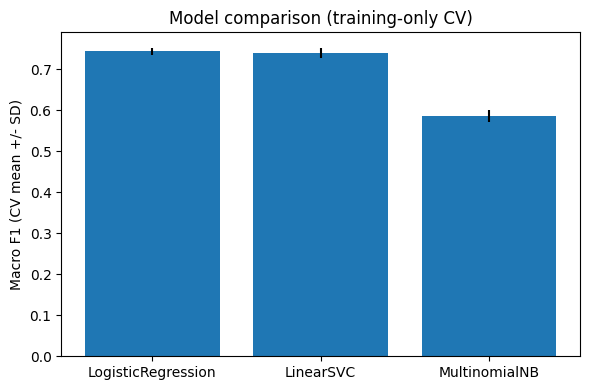

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'MultinomialNB': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.98, sublinear_tf=True)),
        ('clf', MultinomialNB(alpha=0.5))
    ]),
    'LogisticRegression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.98, sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.98, sublinear_tf=True)),
        ('clf', LinearSVC(class_weight='balanced', random_state=SEED))
    ])
}

rows = []
for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'macro_f1':'f1_macro','weighted_f1':'f1_weighted','accuracy':'accuracy'},
        n_jobs=-1, return_train_score=False
    )
    rows.append({
        'model': name,
        'macro_f1_mean': scores['test_macro_f1'].mean(),
        'macro_f1_sd': scores['test_macro_f1'].std(),
        'weighted_f1_mean': scores['test_weighted_f1'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'fit_time_mean': scores['fit_time'].mean()
    })

cv_results = pd.DataFrame(rows).sort_values('macro_f1_mean', ascending=False)
print(cv_results)
cv_results.to_csv(os.path.join(OUT, 'cv_results.csv'), index=False)

plt.figure(figsize=(6,4))
plt.bar(cv_results['model'], cv_results['macro_f1_mean'], yerr=cv_results['macro_f1_sd'])
plt.ylabel('Macro F1 (CV mean +/- SD)'); plt.title('Model comparison (training-only CV)')
plt.tight_layout(); plt.savefig(f'{FIG}/cv_comparison.png'); plt.show()

In [11]:
best_name = cv_results.iloc[0]['model']
best_model = models[best_name]
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

print('Selected model:', best_name)
print(classification_report(y_test, pred, digits=4))
print('Macro F1:', f1_score(y_test, pred, average='macro'))
print('Weighted F1:', f1_score(y_test, pred, average='weighted'))

Selected model: LogisticRegression
              precision    recall  f1-score   support

    negative     0.8905    0.8420    0.8655      1835
     neutral     0.5904    0.7161    0.6472       620
    positive     0.7460    0.6956    0.7199       473

    accuracy                         0.7917      2928
   macro avg     0.7423    0.7512    0.7442      2928
weighted avg     0.8036    0.7917    0.7958      2928

Macro F1: 0.744229670611602
Weighted F1: 0.7957919089209536


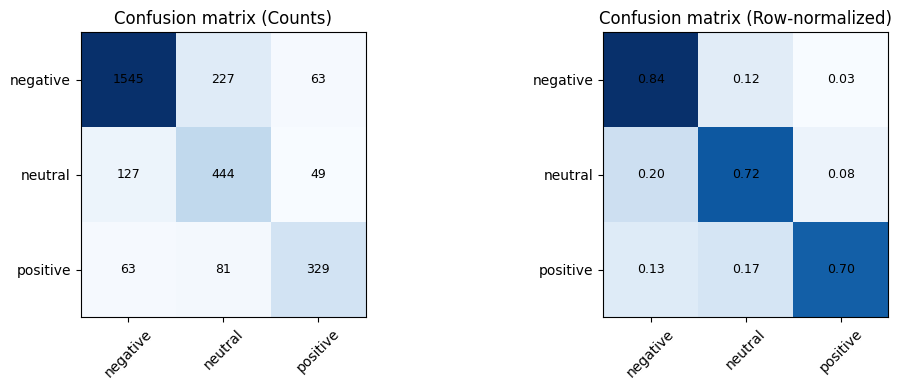

In [12]:
labels_order = sorted(y_test.unique())
cm = confusion_matrix(y_test, pred, labels=labels_order)
cm_norm = confusion_matrix(y_test, pred, labels=labels_order, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, m, title in zip(axes, [cm, cm_norm], ['Counts', 'Row-normalized']):
    im = ax.imshow(m, cmap='Blues')
    ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order, rotation=45)
    ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
    ax.set_title(f'Confusion matrix ({title})')
    for i in range(len(labels_order)):
        for j in range(len(labels_order)):
            ax.text(j, i, f'{m[i,j]:.2f}' if title=='Row-normalized' else f'{m[i,j]}',
                     ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.savefig(f'{FIG}/confusion_matrices.png'); plt.show()

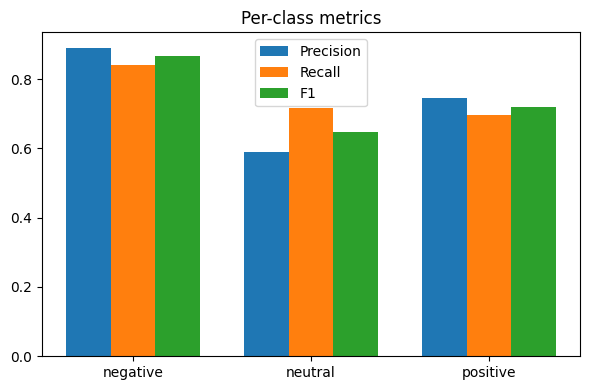

,label,precision,recall,f1,support
0,negative,0.890490,0.841962,0.865546,1835
1,neutral,0.590426,0.716129,0.647230,620
2,positive,0.746032,0.695560,0.719912,473


In [13]:
p, r, f, s = precision_recall_fscore_support(y_test, pred, labels=labels_order)
class_report = pd.DataFrame({'label': labels_order, 'precision': p, 'recall': r, 'f1': f, 'support': s})
class_report.to_csv(os.path.join(OUT, 'class_report.csv'), index=False)

x = np.arange(len(labels_order)); w = 0.25
plt.figure(figsize=(6,4))
plt.bar(x-w, p, w, label='Precision')
plt.bar(x, r, w, label='Recall')
plt.bar(x+w, f, w, label='F1')
plt.xticks(x, labels_order); plt.legend(); plt.title('Per-class metrics')
plt.tight_layout(); plt.savefig(f'{FIG}/per_class_metrics.png'); plt.show()
class_report

In [14]:
test_out = test_df.copy()
test_out['prediction'] = pred
errors = test_out[test_out[TARGET_COL] != test_out['prediction']].copy()

if best_name == 'LogisticRegression':
    proba = best_model.predict_proba(X_test)
    errors['confidence'] = proba.max(axis=1)[test_out[TARGET_COL].values != pred]

sample_errors = errors.sample(min(10, len(errors)), random_state=SEED)[
    [c for c in [TEXT_COL, TARGET_COL, 'prediction', ENTITY_COL] if c in errors.columns]
]
sample_errors.to_csv(os.path.join(OUT, 'error_analysis.csv'), index=False)
sample_errors

,text,airline_sentiment,prediction,airline
3723,@united well it IS John Hughes' birthday. But ...,positive,negative,United
5058,@SouthwestAir do you ever reinstate Cancelled ...,negative,neutral,Southwest
5095,@SouthwestAir are you hiring for flight attend...,neutral,negative,Southwest
10726,@USAirways @AmericanAir thought u merged but #...,negative,neutral,US Airways
8350,@JetBlue yes he and all the princesses. Trying...,neutral,negative,Delta
730,@united Thanks for the lack of help and the ca...,negative,positive,United
12249,@AmericanAir I need refund.,negative,neutral,American
3886,@united Club in Denver is dope 👌,positive,neutral,United
12814,@AmericanAir I'll try to have a great week onc...,negative,positive,American
2795,@united how long does it take for customer fee...,neutral,negative,United


prediction      negative  neutral  positive    N
airline                                         
American           0.647    0.243     0.110  535
Delta              0.447    0.340     0.213  456
Southwest          0.451    0.324     0.225  506
US Airways         0.735    0.168     0.097  565
United             0.654    0.225     0.121  774
Virgin America     0.391    0.370     0.239   92


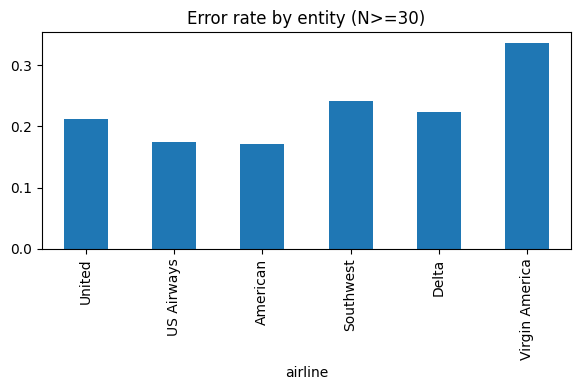

In [15]:
MIN_SUPPORT = 30

if ENTITY_COL in test_out.columns:
    support = test_out[ENTITY_COL].value_counts()
    valid_entities = support[support >= MIN_SUPPORT].index

    entity_summary = pd.crosstab(test_out[ENTITY_COL], test_out['prediction'], normalize='index').round(3)
    entity_summary['N'] = support
    entity_summary = entity_summary.loc[entity_summary.index.intersection(valid_entities)]
    entity_summary.to_csv(os.path.join(OUT, 'entity_sentiment_distribution.csv'))
    print(entity_summary)

    err_rate = test_out.assign(is_error=test_out[TARGET_COL]!=test_out['prediction']) \
                        .groupby(ENTITY_COL)['is_error'].mean().loc[valid_entities]
    err_rate.plot(kind='bar', figsize=(6,4), title='Error rate by entity (N>=30)')
    plt.tight_layout(); plt.savefig(f'{FIG}/error_rate_by_entity.png'); plt.show()

In [16]:
pred_df = test_df[[c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL] if c in test_df.columns]].copy()
pred_df['prediction'] = pred
pred_df.to_csv(os.path.join(OUT, 'test_predictions.csv'), index=False)

joblib.dump(best_model, os.path.join(OUT, 'selected_pipeline.joblib'))
reloaded = joblib.load(os.path.join(OUT, 'selected_pipeline.joblib'))
assert np.array_equal(reloaded.predict(X_test.iloc[:20]), best_model.predict(X_test.iloc[:20]))
print('Reload check passed.')

new_tweets = [
    "The @united crew was amazing, best flight ever!",
    "@AmericanAir cancelled my flight with no notice, terrible service.",
    "Landed on time. Nothing special either way."
]
new_clean = [normalize_tweet(t) for t in new_tweets]
print(list(zip(new_tweets, best_model.predict(new_clean))))

Reload check passed.
[('The @united crew was amazing, best flight ever!', 'positive'), ('@AmericanAir cancelled my flight with no notice, terrible service.', 'negative'), ('Landed on time. Nothing special either way.', 'neutral')]


In [17]:
assert TEXT_COL in df.columns and TARGET_COL in df.columns
assert df[TARGET_COL].nunique() >= 2
assert not df[TEXT_COL].isna().any()
assert len(set(train_df.index).intersection(set(test_df.index))) == 0
assert all(name in models for name in ['LogisticRegression','LinearSVC'])
assert os.path.exists(os.path.join(OUT, 'cv_results.csv'))
assert os.path.exists(os.path.join(OUT, 'selected_pipeline.joblib'))
assert os.path.exists(os.path.join(OUT, 'test_predictions.csv'))
print('Core acceptance tests passed.')

Core acceptance tests passed.


In [18]:
!pip -q install tensorflow transformers datasets evaluate accelerate

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder

print('GPU available:', tf.config.list_physical_devices('GPU'))

ADV_OUT = 'advanced'
os.makedirs(ADV_OUT, exist_ok=True)

MAX_WORDS = 30000
MAX_LEN = 80
EMBED_DIM = 128
SEEDS = [42, 7, 123]  # 3-seed uncertainty requirement (section 17.2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
def build_bilstm(num_classes):
    m = Sequential([
        Embedding(MAX_WORDS, EMBED_DIM),
        Bidirectional(LSTM(64)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tok.fit_on_texts(X_train)
Xtr_seq = pad_sequences(tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
Xte_seq = pad_sequences(tok.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')

le_bilstm = LabelEncoder()
ytr_enc = le_bilstm.fit_transform(y_train)
yte_enc = le_bilstm.transform(y_test)

bilstm_runs = []
histories = []

for seed in SEEDS:
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model = build_bilstm(len(le_bilstm.classes_))
    ckpt_path = os.path.join(ADV_OUT, f'bilstm_seed{seed}.keras')
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, save_best_only=True, monitor='val_loss')
    ]
    t0 = time.time()
    hist = model.fit(Xtr_seq, ytr_enc, validation_split=0.15, epochs=10, batch_size=64,
                      callbacks=callbacks, verbose=1)
    train_time = time.time() - t0

    t0 = time.time()
    proba = model.predict(Xte_seq, batch_size=128)
    infer_time = (time.time() - t0) / len(Xte_seq)

    pred_enc = proba.argmax(axis=1)
    pred_labels = le_bilstm.inverse_transform(pred_enc)
    macro_f1 = f1_score(y_test, pred_labels, average='macro')
    weighted_f1 = f1_score(y_test, pred_labels, average='weighted')
    model_size_mb = os.path.getsize(ckpt_path) / (1024**2)

    bilstm_runs.append({
        'seed': seed, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'train_time_s': train_time, 'infer_latency_s_per_sample': infer_time,
        'model_size_mb': model_size_mb
    })
    histories.append(hist)
    print(f'Seed {seed}: macro F1={macro_f1:.4f}, train_time={train_time:.1f}s')

bilstm_df = pd.DataFrame(bilstm_runs)
bilstm_df.to_csv(os.path.join(ADV_OUT, 'bilstm_multiseed_results.csv'), index=False)
print(bilstm_df)
print('BiLSTM macro F1: mean={:.4f}, sd={:.4f}'.format(bilstm_df['macro_f1'].mean(), bilstm_df['macro_f1'].std()))

Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.6824 - loss: 0.7449 - val_accuracy: 0.7615 - val_loss: 0.6084
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8173 - loss: 0.4680 - val_accuracy: 0.7997 - val_loss: 0.5274
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8917 - loss: 0.3051 - val_accuracy: 0.8036 - val_loss: 0.5746
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9340 - loss: 0.2069 - val_accuracy: 0.7900 - val_loss: 0.7210
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Seed 42: macro F1=0.7189, train_time=37.9s
Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.6806 - loss: 0.7528 - val_accuracy: 0.7615 - val_loss: 0.6001
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8155 - loss: 0.4791 - val_accuracy: 0.8002 - val_loss: 0.5235
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8851 - loss: 0.3229 - val_accuracy: 0.7894 - val_loss: 0.5777
Epoch 4/10
1

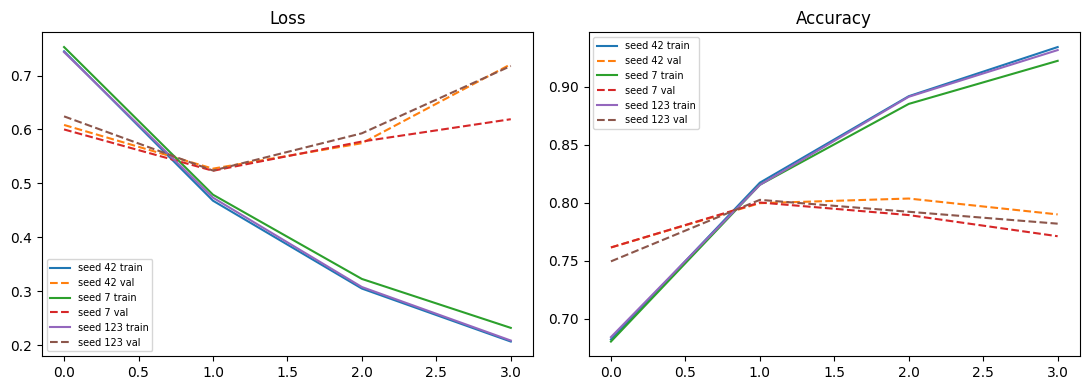

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for i, hist in enumerate(histories):
    axes[0].plot(hist.history['loss'], label=f'seed {SEEDS[i]} train')
    axes[0].plot(hist.history['val_loss'], '--', label=f'seed {SEEDS[i]} val')
    axes[1].plot(hist.history['accuracy'], label=f'seed {SEEDS[i]} train')
    axes[1].plot(hist.history['val_accuracy'], '--', label=f'seed {SEEDS[i]} val')
axes[0].set_title('Loss'); axes[0].legend(fontsize=7)
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig(f'{FIG}/bilstm_learning_curves.png'); plt.show()

In [21]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

MODEL_NAME = 'vinai/bertweet-base'
BERT_SEED = 42

tr_text, val_text, tr_y_raw, val_y_raw = train_test_split(
    X_train, y_train, test_size=0.15, random_state=BERT_SEED, stratify=y_train
)

le_bert = LabelEncoder()
le_bert.fit(y_train)

train_tmp = pd.DataFrame({'text': tr_text.values, 'label': le_bert.transform(tr_y_raw)})
val_tmp   = pd.DataFrame({'text': val_text.values, 'label': le_bert.transform(val_y_raw)})
test_tmp  = pd.DataFrame({'text': X_test.values,   'label': le_bert.transform(y_test)})

train_ds = Dataset.from_pandas(train_tmp, preserve_index=False)
val_ds   = Dataset.from_pandas(val_tmp,   preserve_index=False)
test_ds  = Dataset.from_pandas(test_tmp,  preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(le_bert.classes_))

metric = evaluate.load('f1')
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'macro_f1': metric.compute(predictions=preds, references=labels, average='macro')['f1']}

args = TrainingArguments(
    output_dir=os.path.join(ADV_OUT, 'transformer'),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    seed=BERT_SEED,
    report_to='none'
)

try:
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                       processing_class=tokenizer, compute_metrics=compute_metrics)
except TypeError:
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                       tokenizer=tokenizer, compute_metrics=compute_metrics)

t0 = time.time()
trainer.train()
bert_train_time = time.time() - t0

t0 = time.time()
test_metrics = trainer.evaluate(test_ds)
bert_infer_time = (time.time() - t0) / len(test_ds)

print(test_metrics)

bert_run_config = {
    'model_name': MODEL_NAME, 'tokenizer': MODEL_NAME, 'max_length': 128,
    'batch_size': 16, 'learning_rate': 2e-5, 'epochs': 3, 'weight_decay': 0.01,
    'seed': BERT_SEED, 'train_time_s': bert_train_time,
    'infer_latency_s_per_sample': bert_infer_time
}
with open(os.path.join(ADV_OUT, 'bertweet_run_config.json'), 'w') as f:
    json.dump(bert_run_config, f, indent=2)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Macro F1
0.259291,0.466530,3,0.819168


{'eval_loss': 0.4665301442146301, 'eval_macro_f1': 0.8191681342872131}


In [22]:
preds_logits = trainer.predict(test_ds).predictions
preds_bert = np.argmax(preds_logits, axis=-1)
y_test_enc = le_bert.transform(y_test)

n_boot = 1000
boot_f1 = []
rng = np.random.default_rng(SEED)
n = len(y_test_enc)

for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    boot_f1.append(f1_score(y_test_enc[idx], preds_bert[idx], average='macro'))

boot_f1 = np.array(boot_f1)
ci_low, ci_high = np.percentile(boot_f1, [2.5, 97.5])
bert_macro_f1 = f1_score(y_test_enc, preds_bert, average='macro')
bert_weighted_f1 = f1_score(y_test_enc, preds_bert, average='weighted')

print(f'BERTweet macro F1: {bert_macro_f1:.4f}  95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}]')

model_size_mb_bert = sum(p.numel() for p in model.parameters()) * 4 / (1024**2)

BERTweet macro F1: 0.8192  95% bootstrap CI: [0.8024, 0.8338]


                model  macro_f1              uncertainty  train_time_s  \
0  LogisticRegression  0.744230            CV SD: 0.0082      4.262211   
1              BiLSTM  0.728530    +/-0.0087 (3-seed SD)     24.962274   
2            BERTweet  0.819168  95% CI [0.8024, 0.8338]    389.639535   

   infer_latency_s_per_sample  model_size_mb  
0                    0.000024            NaN  
1                    0.000212      45.218808  
2                    0.002617     514.611340  


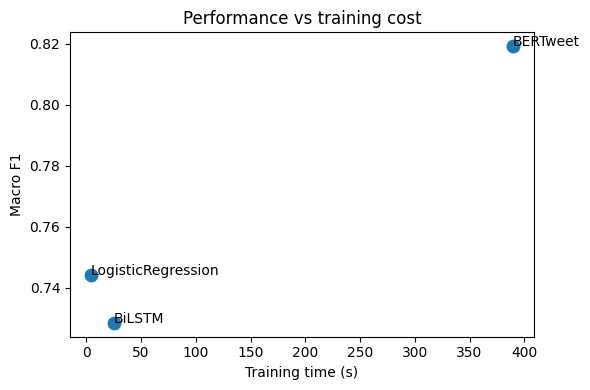

In [23]:
t0 = time.time()
_ = best_model.predict(X_test)
classical_infer_time = (time.time() - t0) / len(X_test)

advanced_comparison = pd.DataFrame([
    {
        'model': best_name, 'macro_f1': f1_score(y_test, best_model.predict(X_test), average='macro'),
        'uncertainty': 'CV SD: ' + str(round(cv_results.iloc[0]['macro_f1_sd'], 4)),
        'train_time_s': cv_results.iloc[0]['fit_time_mean'],
        'infer_latency_s_per_sample': classical_infer_time,
        'model_size_mb': None
    },
    {
        'model': 'BiLSTM', 'macro_f1': bilstm_df['macro_f1'].mean(),
        'uncertainty': f"+/-{bilstm_df['macro_f1'].std():.4f} (3-seed SD)",
        'train_time_s': bilstm_df['train_time_s'].mean(),
        'infer_latency_s_per_sample': bilstm_df['infer_latency_s_per_sample'].mean(),
        'model_size_mb': bilstm_df['model_size_mb'].mean()
    },
    {
        'model': 'BERTweet', 'macro_f1': bert_macro_f1,
        'uncertainty': f"95% CI [{ci_low:.4f}, {ci_high:.4f}]",
        'train_time_s': bert_train_time,
        'infer_latency_s_per_sample': bert_infer_time,
        'model_size_mb': model_size_mb_bert
    }
])
advanced_comparison.to_csv(os.path.join(ADV_OUT, 'efficiency_comparison.csv'), index=False)
print(advanced_comparison)

plt.figure(figsize=(6,4))
plt.scatter(advanced_comparison['train_time_s'], advanced_comparison['macro_f1'], s=80)
for _, row in advanced_comparison.iterrows():
    plt.annotate(row['model'], (row['train_time_s'], row['macro_f1']))
plt.xlabel('Training time (s)'); plt.ylabel('Macro F1')
plt.title('Performance vs training cost')
plt.tight_layout(); plt.savefig(f'{FIG}/perf_vs_runtime.png'); plt.show()

In [24]:
assert os.path.exists(os.path.join(ADV_OUT, 'bilstm_multiseed_results.csv'))
assert os.path.exists(os.path.join(ADV_OUT, 'bertweet_run_config.json'))
assert os.path.exists(os.path.join(ADV_OUT, 'efficiency_comparison.csv'))
assert len(bilstm_df) >= 3, 'Need at least 3 seeds for BiLSTM uncertainty'
print('Advanced acceptance tests passed.')

Advanced acceptance tests passed.
